# Метрики-отношения и дельта-метод 

Статья: https://habr.com/ru/companies/X5Tech/articles/740476/

$$Ratio = \frac{X_1 + ... + X_n}{Y_1 + ... + Y_n}$$

Например, измеряем AOV.     
$X_i$ - сумма покупок i-го покупателя, $Y_i$ - количество покупок i-го покупателя 

Для таких метрик не работает тест Стьюдента, так как в приницпе тут метрика непонятно как распределена. 

Но можно представить, что у в выборке стоимости вообще всех покупок.    
А тогда в этой выборке будет несколько покупок от одного пользователя - зависимые величины.     
И поэтому тоже ttest не работает

**Чтобы проверить гипотезу, можно сделать Bootstrap**

Основная особенность применение бутстрепа для метрик отношения — данные необходимо семплировать по объектам (пользователям), а не по наблюдениям.   
Так как бутстреп предполагает, чтобы объекты независимы     

**Оказывается, тест Стьюдента можно применить, если использовать Дельта-метод**

Суть в том, чтобы с помощью Taylor expansion найти распределение нашей Ratio метрики

$$Ratio = \frac{X_1 + ... + X_n}{Y_1 + ... + Y_n} = \frac{\bar{X}}{\bar{Y}} = g(\bar{X}, \bar{Y})$$

> Находим распределение для Ratio метрики

1. The Multivariate CLT for the Vector

$$\sqrt{n} \left( \begin{pmatrix} \bar{X} \\ \bar{Y} \end{pmatrix} - \begin{pmatrix} \mu_x \\ \mu_y \end{pmatrix} \right) \xrightarrow{d} N(0, \Sigma_{2x2})$$

2. The Linearization (The "Delta" Part) - using Taylor expansion in point $(\mu_x, \mu_y)$

$$g(\bar{X}, \bar{Y}) - g(\mu_x, \mu_y) \approx \underbrace{\nabla g^T}_{\text{The "Delta"}} \cdot \begin{pmatrix} \bar{X} - \mu_x \\ \bar{Y} - \mu_y \end{pmatrix}$$

> Это есть исходная величина, умноженная на константу, 
> поэтому она тоже распределена нормально!

$$\nabla g = \begin{pmatrix} \frac{\partial g}{\partial x} \\ \frac{\partial g}{\partial y} \end{pmatrix}$$


3. Now we  take the CLT result and "push" it through that linear transformation:    

$$\sqrt{n}(\nabla g^T \cdot \begin{pmatrix} \bar{X} - \mu_x \\ \bar{Y} - \mu_y \end{pmatrix}) \xrightarrow{d} N(0, \underbrace{\nabla g^T \Sigma \nabla g}_{\text{Transformed Variance}})$$

$$\sqrt{n}(g(\bar{X}, \bar{Y}) - g(\mu_x, \mu_y)) \xrightarrow{d} N(0, \nabla g^T \Sigma \nabla g)$$

> То есть, мы получили, что $\frac{X}{Y} = g(\bar{X}, \bar{Y})$ распределена нормально, где 

$$\mathbb{V}\left(\frac{X}{Y}\right) = \mathbb{V}(g(\bar{X}, \bar{Y})) = \frac{1}{n}\nabla g^T \Sigma \nabla g \approx \frac{1}{n} \left(\frac{1}{\mu_y^2} \mathbb{V}(X) - 2\frac{\mu_x}{\mu_y^3} \text{cov}(X, Y) + \frac{\mu_x^2}{\mu_y^4} \mathbb{V}(Y)\right)$$

$$\mathbb{E}\left(\frac{X}{Y}\right) = \mathbb{E}(g(\bar{X}, \bar{Y})) \approx g(\mu_x, \mu_y) = \frac{\mu_x}{\mu_y}$$

----

Другой способ 

Используем то же разложение в ряд Тейлора в точке $(\mathbb{E} X, \mathbb{E}Y)$

$$Ratio = \frac{X_1 + ... + X_n}{Y_1 + ... + Y_n} = \dfrac{\overline{X}}{\overline{Y}} \approx \dfrac{\mathbb{E} X}{\mathbb{E} Y} + \dfrac{1}{\mathbb{E} Y}\left(\overline{X} - \dfrac{\mathbb{E} X}{\mathbb{E} Y}\overline{Y} \right) = \\ \\
\ 

= \frac{1}{n} \sum \ \dfrac{\mathbb{E} X}{\mathbb{E} Y} + \dfrac{1}{\mathbb{E} Y}\left(X_i - \dfrac{\mathbb{E} X}{\mathbb{E} Y}Y_i \right) = \frac{1}{n} \sum Z_i$$

Что мы получили? Теперь наша Ratio метрика это просто среднее $Z_i$, которые независимы. И мы можем сделать обычный ttest. Конечно, мы не знаем $\mathbb{E}X$ и $\mathbb{E}Y$, но можем их заменить на оценки $\overline{X}$, $\overline{Y}$, которые по ЗБЧ сходятся к матожиданию

> И здесь мы даже не пересчитываем новую дисперсию 

In [1]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [13]:
# Проверяем, что обычный тест Стьюдента не работает 
# Видим, что Type I завышен, то есть таким критерием пользоваться нельзя

# Делаем выбоку А без эффекта и B с эффектом
def generate_data(sample_size,  effect):
    result = []

    for effect in [0, effect]:
        n_purchases = np.random.randint(1, 5, sample_size)
        mean_costs = np.random.uniform(1000, 2000, sample_size)
        # Генерируем сами покупки для i-го пользователя
        data = [
            stats.norm(loc=mean+effect, scale=200).rvs(n) for mean, n in zip(mean_costs, n_purchases)
        ]
        result.append(data)

    return result

alpha = 0.05
sample_size = 300

# Делаем Монте-Карло, АА тест
pvalues = []
n_iter = 1000
for _ in tqdm(range(n_iter)):
    control, test = generate_data(sample_size, 0)
    control = np.hstack(control)
    test = np.hstack(test)
    pvalue = stats.ttest_ind(control, test).pvalue
    pvalues.append(pvalue)

100%|██████████| 1000/1000 [01:22<00:00, 12.07it/s]


In [7]:
def plot_pvalue_distribution(dict_pvalues):
    """Рисует графики распределения p-value."""
    X = np.linspace(0, 1, 1000)
    for name, pvalues in dict_pvalues.items():
        # Эмпирическая CDF для pvalue
        Y = [np.mean(pvalues < x) for x in X]
        plt.plot(X, Y, label=name)

    plt.plot([0, 1], [0, 1], '--k', alpha=0.8)
    plt.title('Оценка распределения p-value', size=16)
    plt.xlabel('p-value', size=12)
    plt.legend(fontsize=12)
    plt.grid()
    plt.show()

Type I: 0.192
CI: [0.169, 0.218]


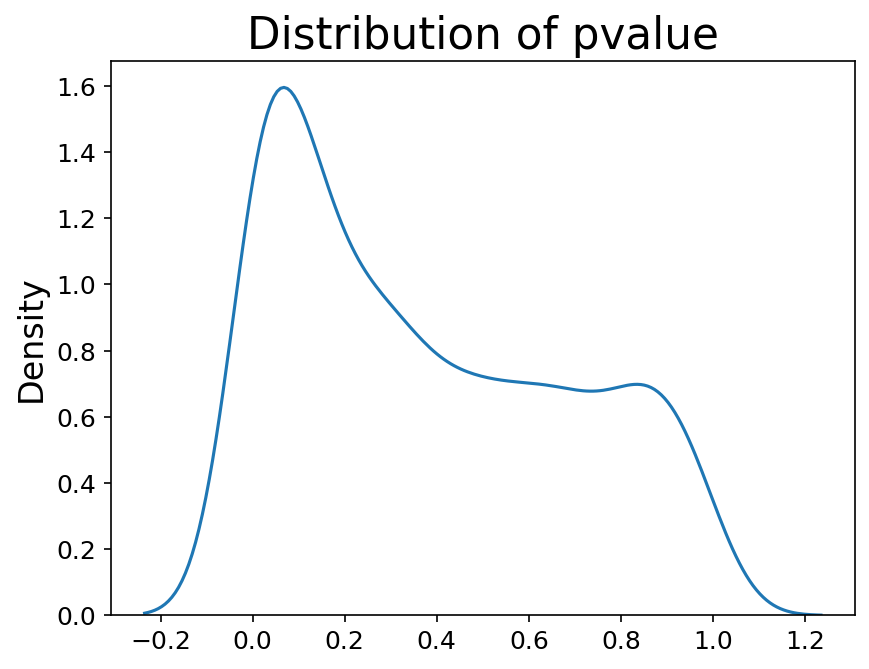

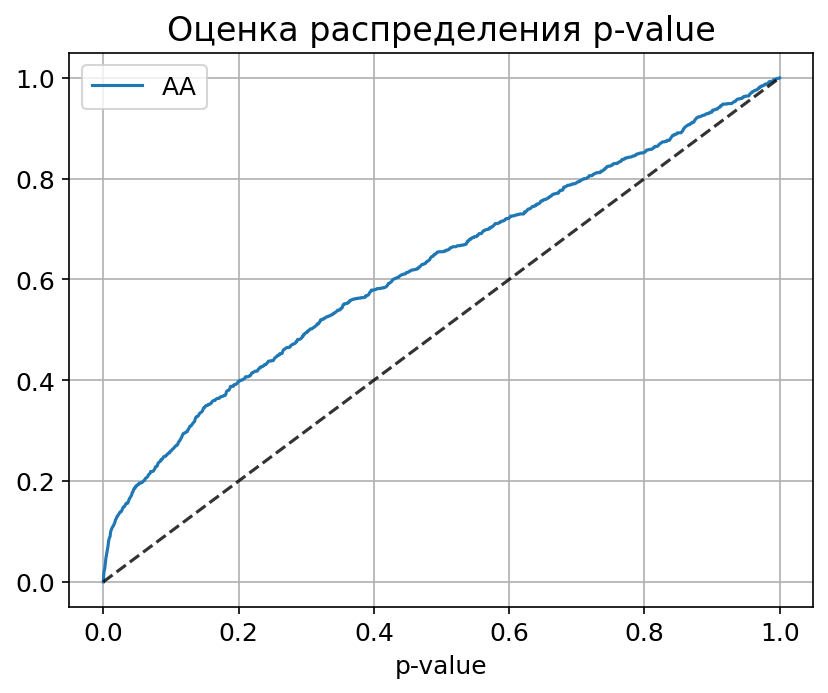

In [11]:
pvalues = np.array(pvalues)

# Выводим полученный Type I и CI для него
type_one = np.mean(pvalues <= alpha)
print(f"Type I: {type_one:.3f}")
ci_left, ci_right = proportion_confint(count=np.sum(pvalues <= alpha), nobs=len(pvalues), alpha=0.05, method='wilson')
print(f"CI: [{ci_left:.3f}, {ci_right:.3f}]")

# Рисуем pdf для pvalue 
sns.kdeplot(pvalues)
plt.title("Distribution of pvalue")
plt.show()

# рисуем эмпирическую CDF pvalue
plot_pvalue_distribution({"AA": pvalues})

In [ ]:
# А теперь делаем трюк: Объединим для каждого пользователя его покупки 
# Но при этом среднее средних не является средним, поэтому это тоже не совсем правильно

# Делаем Монте-Карло, АА тест
pvalues = []
n_iter = 1000
for _ in tqdm(range(n_iter)):
    control, test = generate_data(sample_size, 0)
    control = [np.mean(x) for x in control]
    test = [np.mean(x) for x in test]
    pvalue = stats.ttest_ind(control, test).pvalue
    pvalues.append(pvalue)

Type I: 0.040
CI: [0.030, 0.054]


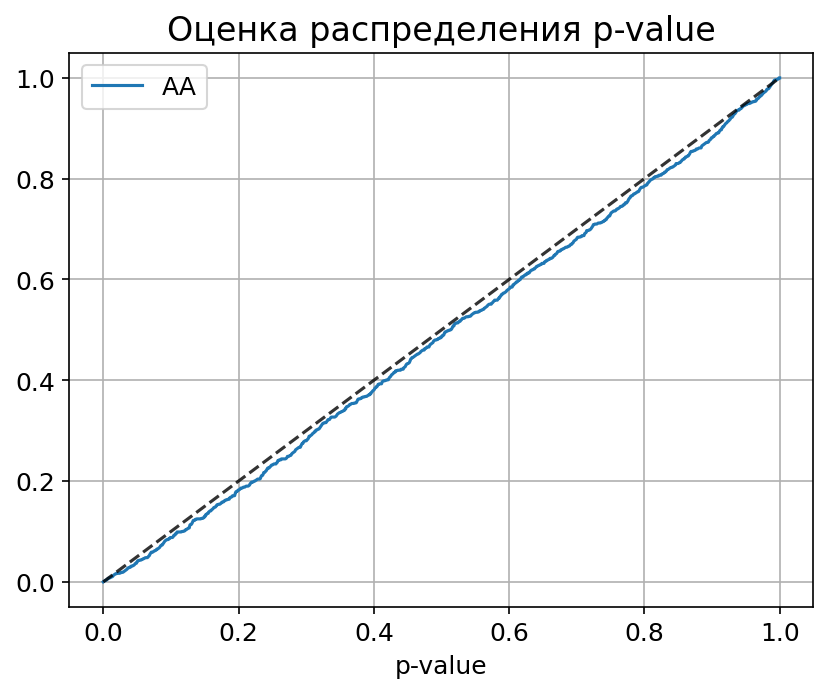

In [15]:
pvalues = np.array(pvalues)

# Выводим полученный Type I и CI для него
type_one = np.mean(pvalues <= alpha)
print(f"Type I: {type_one:.3f}")
ci_left, ci_right = proportion_confint(count=np.sum(pvalues <= alpha), nobs=len(pvalues), alpha=0.05, method='wilson')
print(f"CI: [{ci_left:.3f}, {ci_right:.3f}]")

# рисуем эмпирическую CDF pvalue
plot_pvalue_distribution({"AA": pvalues})

In [24]:
# Делаем Bootstrap 
# Логика: семплируем выборки, далее делаем Bootstrap, чтобы посчитать нашу метрку отношения и доверительнй интервал для нее
# Если CI включает 0, то метрика изменилась
# Проводим все это много раз, чтобы понять, в каком проценте случаем метрика изменилась

def get_percentile_ci(bootstrap_stats, estimated_value, alpha):
    ci_left, ci_right = np.quantile(bootstrap_stats, [alpha / 2, 1 - alpha / 2])
    return ci_left, ci_right

def get_bootstrap(sample_a, sample_b, n_iter, alpha):
    # sample_a = [[1, 2, 3], [4, 5, 6], ...] - стоимости покупок пользователей
    # Группируем по пользователям
    group_a = np.array([[sum(x), len(x)] for x in sample_a])
    group_b = np.array([[sum(x), len(x)] for x in sample_b])

    # Выбираем индексы с возвращаем (по пользователям)
    indices_a = np.random.choice(
        np.arange(len(group_a)), size=(n_iter, len(group_a)), replace=True
    )
    indices_b = np.random.choice(
        np.arange(len(group_b)), size=(n_iter, len(group_b)), replace=True
    )

    bootstrap_stats = []
    for idx_a, idx_b in zip(indices_a, indices_b):
        # Для данной итерации находим выбранные группы
        a = group_a[idx_a] # [[1, 1], [2, 3]]
        b = group_b[idx_b]

        # Считаем метрику отношения
        ratio_a = a[:, 0].sum() / a[:, 1].sum()
        ratio_b = b[:, 0].sum() / b[:, 1].sum()

        diff = ratio_b - ratio_a
        bootstrap_stats.append(diff)
    
    # Считаем доверительный интервал
    ci_left, ci_right = get_percentile_ci(bootstrap_stats=bootstrap_stats, estimated_value=0, alpha=alpha)
    has_effect = not (ci_left < 0 < ci_right)

    return has_effect

alpha = 0.05
sample_size = 300

# Делаем AA тест и смотрим на type I
effects = []
n_iter = 1000
for _ in tqdm(range(300)):
    control, test = generate_data(sample_size, 0) # AA test, effect = 0
    
    effect = get_bootstrap(control, test, n_iter, alpha)
    effects.append(effect)

effects = np.array(effects)

print(f"Type I: {np.mean(effects):.3f}")


100%|██████████| 300/300 [00:26<00:00, 11.43it/s]

Type I: 0.060


100%|██████████| 300/300 [00:48<00:00,  6.25it/s]


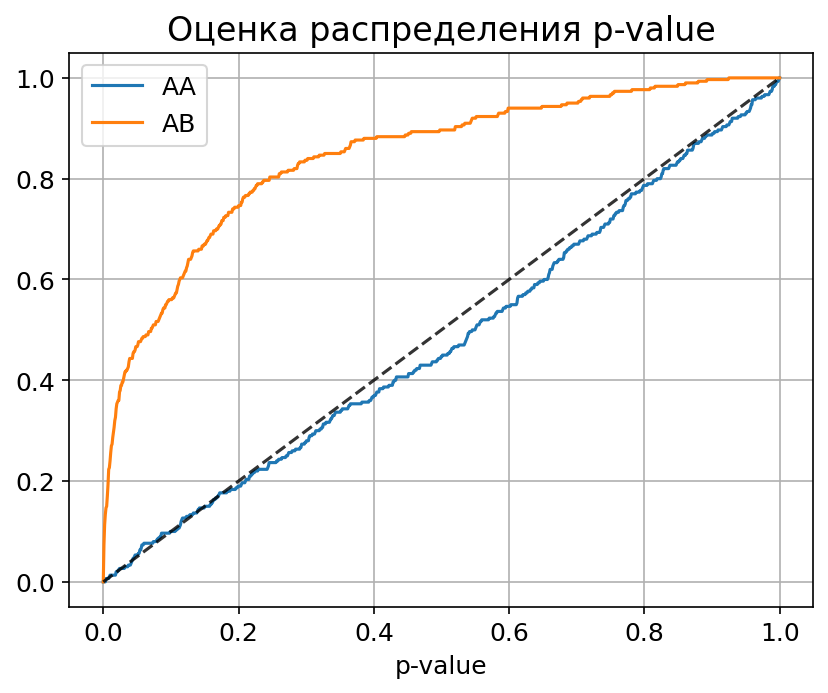

In [28]:
# Теперь сделаем тесть Стьюдента с скорректированной дисперсией 

def correct_ttest(control, test):

    # Считает оценку и дисперсию для метрики отношения
    def get_ratio_pe_var(sample):
        # sample = [[1, 2, 3], [4, 5, 6]] - суммы покупок пользователей
        flattened = np.hstack(sample)

        pe = np.sum(flattened) / len(flattened)

        x_array = np.array([np.sum(x) for x in sample])
        y_array = np.array([len(x) for x in sample])

        mean_x = x_array.mean()
        mean_y = y_array.mean()
        var_x = x_array.var()
        var_y = y_array.var()
        cov_xy = np.cov(x_array, y_array)[0, 1]

        var = (
            var_x / mean_y ** 2 - 2 * (mean_x / mean_y ** 3) * cov_xy + (mean_x ** 2 / mean_y ** 4) * var_y
        ) / len(sample)

        return pe, var
    
    # Теперь делаем ttest для разницы метрик отношения в контроле и тесте
    
    pe_control, var_control = get_ratio_pe_var(control)
    pe_test, var_test = get_ratio_pe_var(test)

    pe = pe_test - pe_control
    var = var_control + var_test

    t = pe / np.sqrt(var)

    pvalue = 2 * min(stats.norm().cdf(t), 1 - stats.norm().cdf(t))

    return pvalue

alpha = 0.05
sample_size = 300
effect = 50

# Monte Carlo to estimate pvalues and check correctness
pvalues_aa = []
pvalues_ab = []
n_iter = 300
for _ in tqdm(range(n_iter)):
    control_aa, test_aa = generate_data(sample_size, 0)
    control_ab, test_ab = generate_data(sample_size, effect)

    pvalue_aa = correct_ttest(control_aa, test_aa)
    pvalue_ab = correct_ttest(control_ab, test_ab)

    pvalues_aa.append(pvalue_aa)
    pvalues_ab.append(pvalue_ab)

plot_pvalue_distribution({'AA': pvalues_aa, 'AB': pvalues_ab})